# GVHD project integrated analysis

In [3]:

#!pip install openpyxl
#anndata needs to be 0.8.0
from glob import glob
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import anndata
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc
import tarfile
import seaborn as sns
import scvi
import torch

from collections import OrderedDict
import pickle
#import scrublet as scr
import scipy.io
import matplotlib.pyplot as plt
import os

In [4]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()
sc.set_figure_params(dpi=80)

# Loading data

In [5]:
#!pip install openpyxl

In [6]:
filtered_combined = anndata.read_h5ad('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/anndata_file/filtered_combined_all_PatientID_f.h5ad')

/Users/lingting/ENTER/envs/mrvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [7]:
filtered_combined.obs_names_make_unique()

In [8]:
filtered_combined

AnnData object with n_obs × n_vars = 115901 × 38012
    obs: 'PatientID', 'SampleID', 'FreshorFrozen', 'Days_post-Transplant', 'Tissue_Location', 'LPorIE', 'Enrichment Method', 'Pathological_grade_of_GVHD', 'Pathological_grade_of_GVHD_num', 'Grade_num', 'GVHD_Grade_1', 'GVHD_Grade_2', 'GVHD_Grade_3', 'Transplant_Conditioning', 'Gender', 'Time_1stGVHD', 'Donor', 'Disease', 'GVHD_Prophylaxis_Regimen', 'Dates_from_Transplantation', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'is_doublet', 'leiden', 'leiden_old', 'leiden_0.15'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'PatientID_colors', 'hvg', 'leiden', 'leiden_0.15_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap', 'scvi'
    layers: 'counts'
    obsp: 'connectivities', 'distan

# Stack plots on cell proportion

In [9]:
from copy import deepcopy

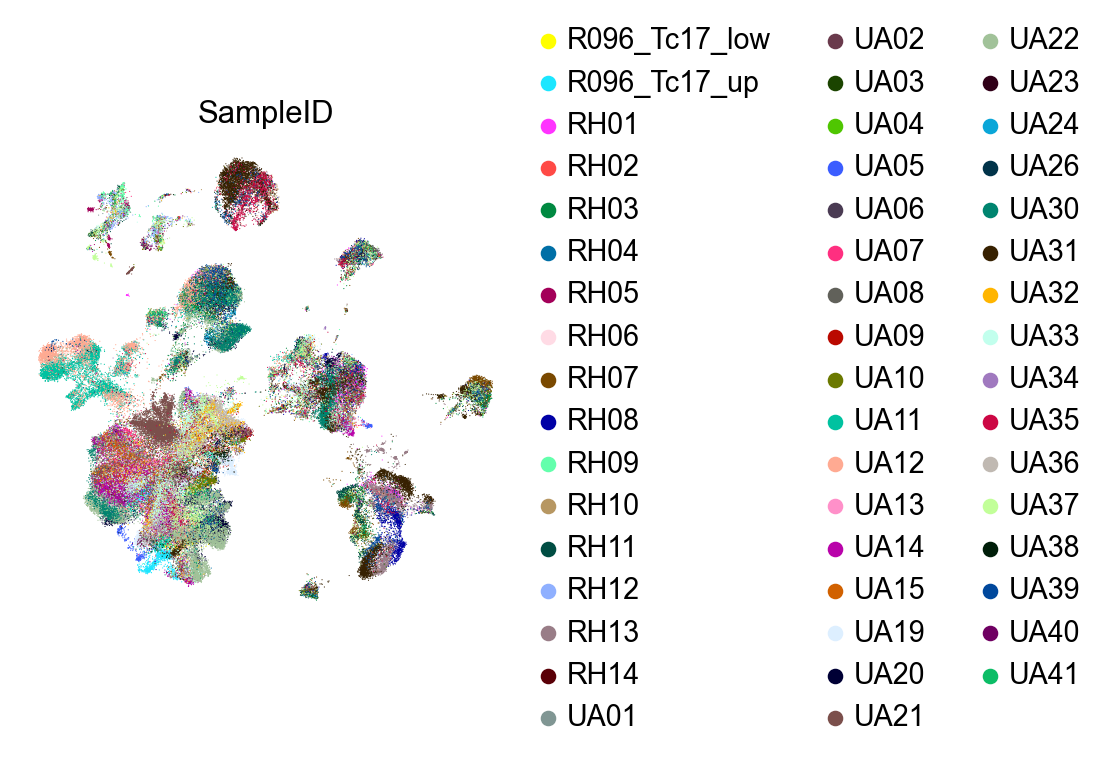

In [10]:
sc.pl.umap(filtered_combined, color=['SampleID'], frameon=False)

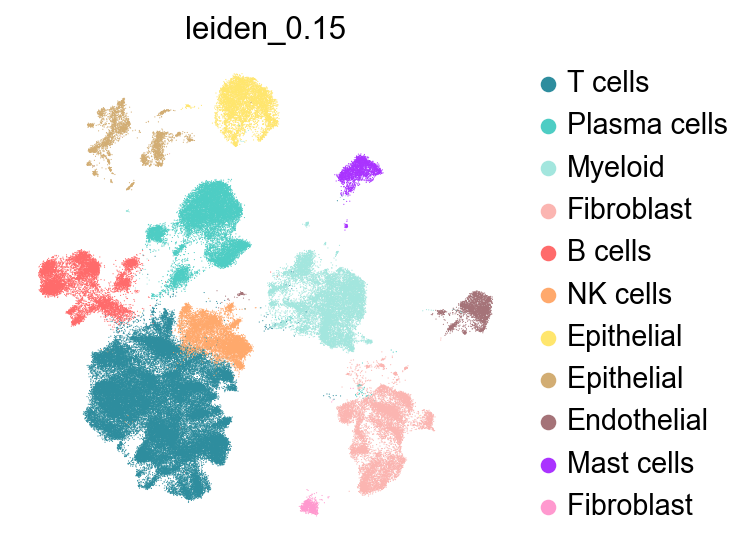

In [11]:
sc.pl.umap(filtered_combined, color=['leiden_0.15'], frameon=False)

In [12]:
# Extract the color list from Tcell_sc_3_7000deg.uns['leiden_0.5_colors']

#new_cluster_names = ['T_cells','Plasma_cells',"Myeloid","Fibroblast","B_cells","NK_cells","Epithelial","Epithelial_2",'Endothelial', "Mast_cells","Fibroblast_2"]
#filtered_combined.rename_categories('leiden_0.15', new_cluster_names)
colors = filtered_combined.uns['leiden_0.15_colors']

# Extract unique cluster labels from Tcell_sc_3_7000deg.obs['leiden_0.5']
unique_clusters = filtered_combined.obs['leiden_0.15'].cat.categories

# Create a mapping from cluster labels to colors
cluster_colors = {cluster: color for cluster, color in zip(unique_clusters, colors)}
print(cluster_colors)

{'T cells': '#2E8D9E', 'Plasma cells': '#4ECDC4', 'Myeloid': '#A3E6DE', 'Fibroblast': '#FBB5B1', 'B cells': '#FF6B6B', 'NK cells': '#FFA96C', 'Epithelial': '#FFE66D', 'Epithelial ': '#D2AD73', 'Endothelial': '#A57378', 'Mast cells': '#AA33FF', 'Fibroblast ': '#FF99CF'}


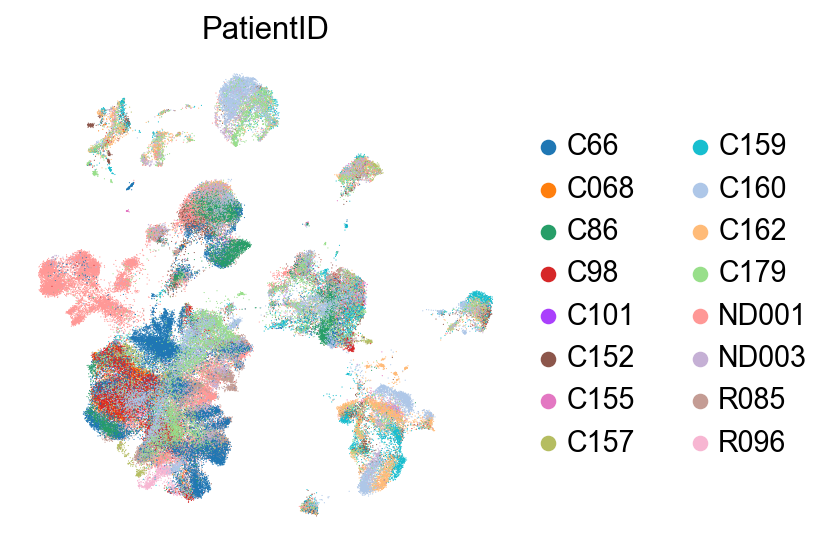

In [13]:
sc.pl.umap(filtered_combined, color=['PatientID'], frameon=False)

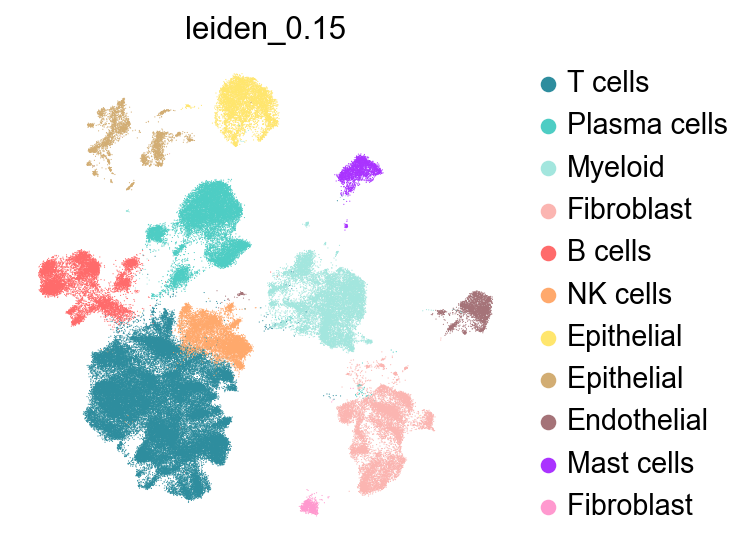

In [14]:
sc.pl.umap(filtered_combined, color=['leiden_0.15'], frameon=False)

In [15]:
# Update meta file information

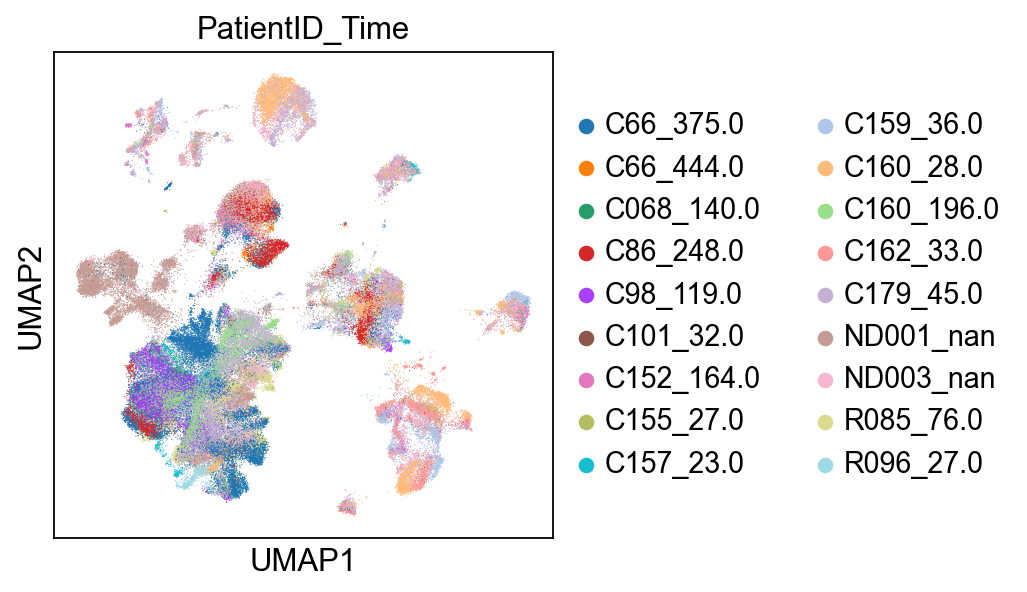

In [16]:
filtered_combined.obs.loc[filtered_combined.obs['PatientID']=='C179','GVHD_Grade_1'] = "Mild"
filtered_combined.obs.loc[filtered_combined.obs['PatientID']=='R085','GVHD_Grade_1'] = "No"

filtered_combined.obs['GVHD_Grade_1'] = filtered_combined.obs['GVHD_Grade_1'].astype('category')
filtered_combined.obs['GVHD_Grade_1'] = filtered_combined.obs['GVHD_Grade_1'].cat.add_categories(['Treated'])
filtered_combined.obs.loc[filtered_combined.obs['Days_post-Transplant']==444.0,'GVHD_Grade_1'] = "Treated"



filtered_combined.obs['PatientID_Time'] = filtered_combined.obs['PatientID'].astype(str)+'_'+filtered_combined.obs['Days_post-Transplant'].astype(str)

sc.pl.umap(filtered_combined, color=['PatientID_Time'],ncols=2)

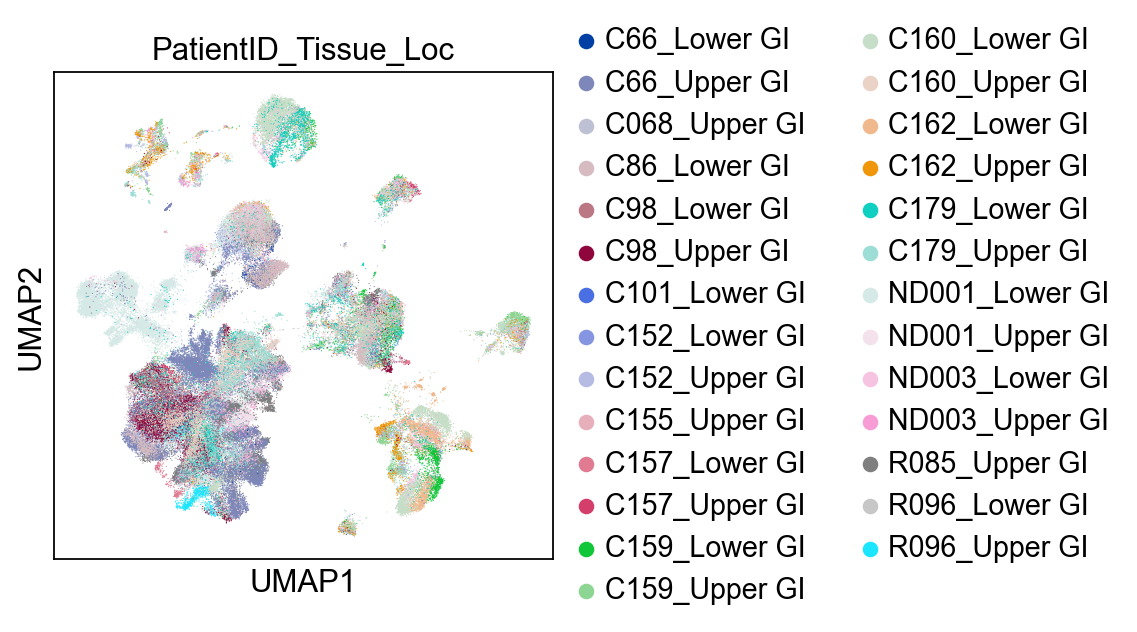

In [17]:
filtered_combined.obs['PatientID_Tissue_Loc'] = filtered_combined.obs['PatientID'].astype(str)+'_'+filtered_combined.obs['Tissue_Location'].astype(str)

filtered_combined.obs['PatientID_Tissue_Loc'] = filtered_combined.obs['PatientID'].astype(str)+'_'+filtered_combined.obs['Tissue_Location'].astype(str)

filtered_combined.obs.loc[filtered_combined.obs['PatientID_Tissue_Loc']=='C162_Upper GI','GVHD_Grade_1'] = "No"
filtered_combined.obs.loc[filtered_combined.obs['PatientID_Time']=='C160_28.0','GVHD_Grade_1'] = "Mild"
filtered_combined.obs.loc[filtered_combined.obs['PatientID_Time']=='C160_196.0','GVHD_Grade_1'] = "No"

filtered_combined.obs['PatientID_Grade'] = filtered_combined.obs['PatientID'].astype(str)+'_'+filtered_combined.obs['GVHD_Grade_1'].astype(str)

sc.pl.umap(filtered_combined, color=['PatientID_Tissue_Loc'],ncols=2)

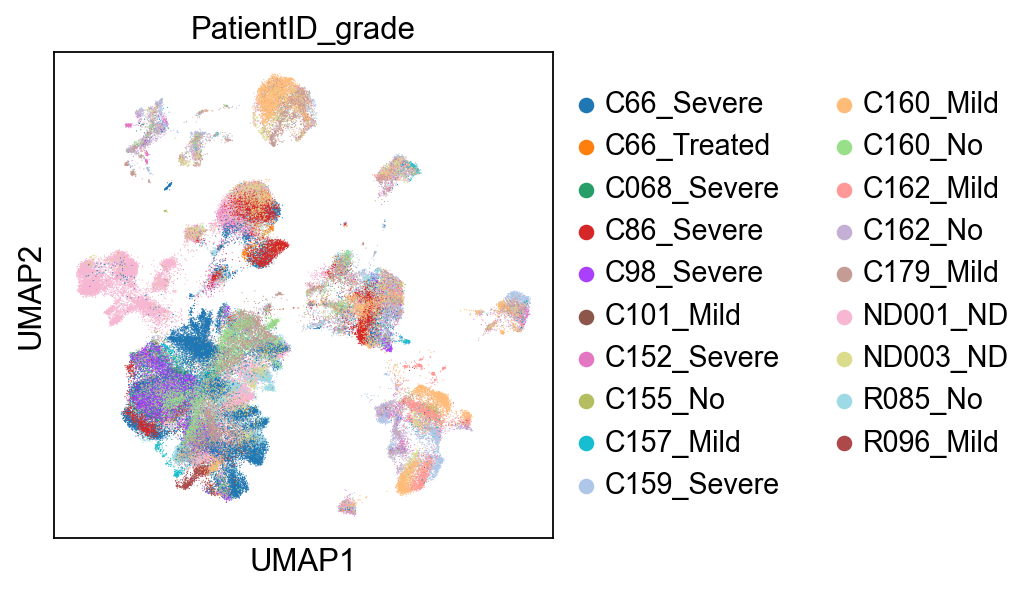

In [18]:
filtered_combined.obs['PatientID_grade'] = filtered_combined.obs['PatientID'].astype(str)+'_'+filtered_combined.obs['GVHD_Grade_1'].astype(str)
sc.pl.umap(filtered_combined, color=['PatientID_grade'],ncols=2)


In [19]:
filtered_combined.obs['SampleID_Grade'] = filtered_combined.obs['SampleID'].astype(str)+'_'+filtered_combined.obs['GVHD_Grade_1'].astype(str)

In [20]:
imm_celltype = ['T cells', "Plasma cells","Myeloid",'B cells','NK cells','Mast Cells']
imm_filtered_combined = filtered_combined[filtered_combined.obs['leiden_0.15'].isin(imm_celltype)]

In [21]:
imm_filtered_combined.obs['SampleID_Grade'] = imm_filtered_combined.obs['SampleID_Grade'].astype('category')
imm_filtered_combined.obs['leiden_0.15'] = imm_filtered_combined.obs['leiden_0.15'].astype('category')

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_78431/2880922078.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  imm_filtered_combined.obs['SampleID_Grade'] = imm_filtered_combined.obs['SampleID_Grade'].astype('category')


In [22]:
filtered_combined.obs['leiden_0.15']

AAACCTGCATCCCACT-1         T cells
AAACCTGGTTGGAGGT-1         T cells
AAACCTGTCTATCCTA-1         T cells
AAACGGGAGGATGCGT-1         T cells
AAACGGGGTAAATGAC-1         T cells
                          ...     
TTGGCAATCGTAGATC-1    Plasma cells
TTGTAGGAGAGGTAGA-1         Myeloid
TTGTAGGAGTGCAAGC-1      Mast cells
TTGTAGGGTCATATGC-1     Epithelial 
TTTACTGCACCAGATT-1    Plasma cells
Name: leiden_0.15, Length: 115901, dtype: category
Categories (11, object): ['T cells', 'Plasma cells', 'Myeloid', 'Fibroblast', ..., 'Epithelial ', 'Endothelial', 'Mast cells', 'Fibroblast ']

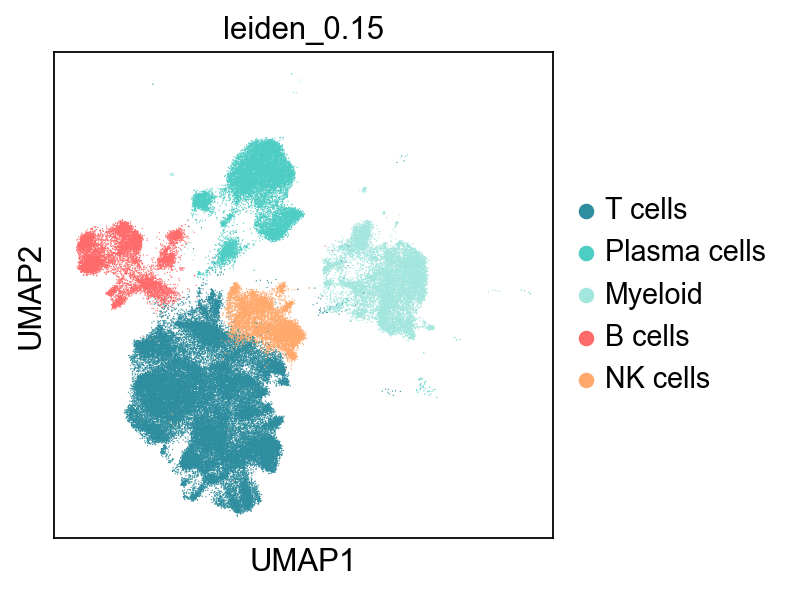

In [23]:
sc.pl.umap(imm_filtered_combined, color=['leiden_0.15'])

# Figure 4B

In [24]:
import matplotlib as mpl
# Update your existing rcParams
mpl.rcParams.update({
    'font.size': 8,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
    'figure.figsize': (2.5, 2.5)  # Set default figure size to 6×4 inches
})
mpl.rcParams['axes.titlesize'] = 8
mpl.rcParams['xtick.labelsize'] = 8  # Colorbar tick label size 
mpl.rcParams['ytick.labelsize'] = 8  # Colorbar tick label size

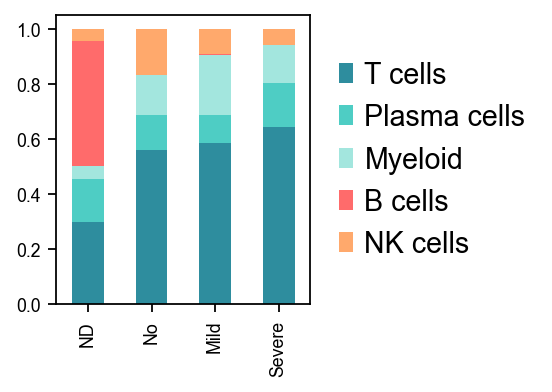

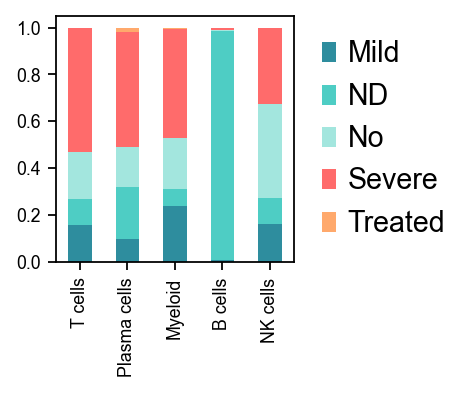

In [25]:
sorter_grade = ['ND','No','Mild','Severe']

obs_1 = 'GVHD_Grade_1'
obs_2 = 'leiden_0.15'

n_categories = {x : len(imm_filtered_combined.obs[x].cat.categories) for x in [obs_1, obs_2]}
df = imm_filtered_combined.obs[[obs_2, obs_1]].values

obs2_clusters = imm_filtered_combined.obs[obs_2].cat.categories.tolist()
obs1_clusters = imm_filtered_combined.obs[obs_1].cat.categories.tolist()

obs1_to_obs2 = {k: np.zeros(len(obs2_clusters), dtype="i")
                   for k in obs1_clusters}
obs2_to_obs1 = {k: np.zeros(len(obs1_clusters), dtype="i")
                   for k in obs2_clusters}

for b, l in df:
  obs2_to_obs1[b][obs1_clusters.index(str(l))] += 1
  obs1_to_obs2[l][obs2_clusters.index(str(b))] += 1

obs2_to_obs1_array = np.zeros((len(obs2_clusters), len(obs1_clusters)))
obs1_to_obs2_array = np.zeros((len(obs1_clusters), len(obs2_clusters)))

for i, k in enumerate(obs2_clusters):
  obs2_to_obs1_array[i, :] = deepcopy(obs2_to_obs1[k])
for i, k in enumerate(obs1_clusters):
  obs1_to_obs2_array[i, :] = deepcopy(obs1_to_obs2[k])

sums = np.sum(obs2_to_obs1_array, 0)
for col in range(np.size(obs2_to_obs1_array, 1)):
  for row in range(np.size(obs2_to_obs1_array, 0)):
    obs2_to_obs1_array[row, col] = obs2_to_obs1_array[row, col] / sums[col]

sums2 = np.sum(obs1_to_obs2_array, 0)
for col in range(np.size(obs1_to_obs2_array, 1)):
  for row in range(np.size(obs1_to_obs2_array, 0)):
    obs1_to_obs2_array[row, col] = obs1_to_obs2_array[row, col] / sums2[col]



df_obs2 = pd.DataFrame(obs2_to_obs1_array)
df_obs2.index = obs2_clusters
df_obs2.columns = obs1_clusters
df_obs2 = df_obs2.reindex(columns=sorter_grade)

df_obs1 = pd.DataFrame(obs1_to_obs2_array)
df_obs1.index = obs1_clusters
df_obs1.columns = obs2_clusters


# For the first plot using df_obs2
leiden_colors = imm_filtered_combined.uns['leiden_0.15_colors']
df_obs2 = df_obs2.reindex(columns=sorter_grade)
ax = df_obs2.T.plot(kind="bar", 
                    stacked=True, 
                    color=leiden_colors,  # Use the leiden colors
                    figsize=(3.5,2.5))
plt.legend(bbox_to_anchor=(1.01, 0.5), loc='center left',frameon = False)
plt.grid(False)
plt.tight_layout()
plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/immune_cell_type_bar_plot.png', 
            dpi=300, 
            bbox_inches='tight', transparent = True)
plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/immune_cell_type_bar_plot.pdf', 
            dpi=300, 
            bbox_inches='tight', transparent = True)
plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/immune_cell_type_bar_plot.svg', 
            dpi=300, 
            bbox_inches='tight', transparent = True)
plt.show()

# For the second plot using df_obs1
ax = df_obs1.T.plot(kind="bar", 
                    stacked=True, 
                    color=leiden_colors,  # Use the leiden colors
                    figsize=(3, 2.5))
plt.legend(bbox_to_anchor=(1.01, 0.5), loc='center left',frameon = False)
plt.grid(False)
plt.tight_layout()
plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/immune_cell_type_bar_plot_2.png', 
            dpi=300, 
            bbox_inches='tight')
plt.savefig('/Users/lingting/Documents/GVHD_project/Paper_ready_pipeline/Figures/single_cell_figures/immune_cell_type_bar_plot_2.pdf', 
            dpi=300, 
            bbox_inches='tight')
plt.show()